In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (10886, 12)


In [4]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10886
Number of columns: 12


The dataset contains 10,886 hourly observations and 12 variables, providing information about time, weather conditions, and bike rental demand.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


The dataset has no missing values. The variables include numerical and categorical data, while datetime is currently stored as an object and will be converted to a datetime format for further analysis.


In [7]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000




The descriptive statistics indicate substantial variation in both weather conditions and bike rental demand. The count variable ranges from 1 to 977 rentals per hour, highlighting significant differences in hourly demand.


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309




The dataset contains categorical variables with a limited number of distinct values, while numerical variables show greater variation. The datetime column contains a unique value for each record.

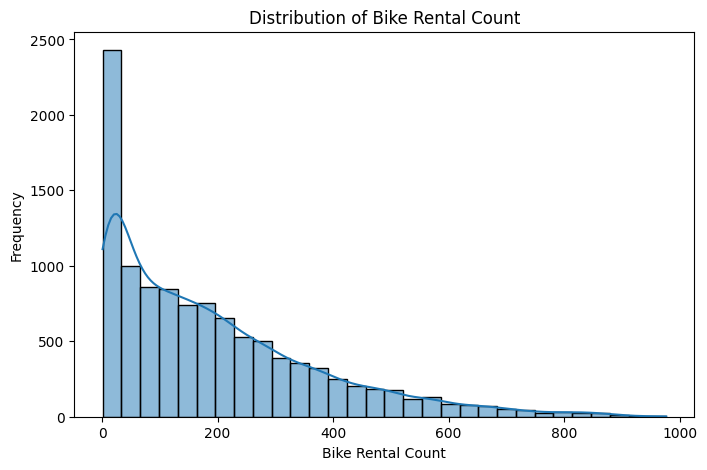

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['count'], bins=30, kde=True)
plt.title('Distribution of Bike Rental Count')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')
plt.show()



The distribution of bike rental counts is positively skewed, with most observations having relatively low rental counts and fewer observations showing very high demand. This indicates substantial variation in rental demand and suggests that a target transformation may be considered during modeling.

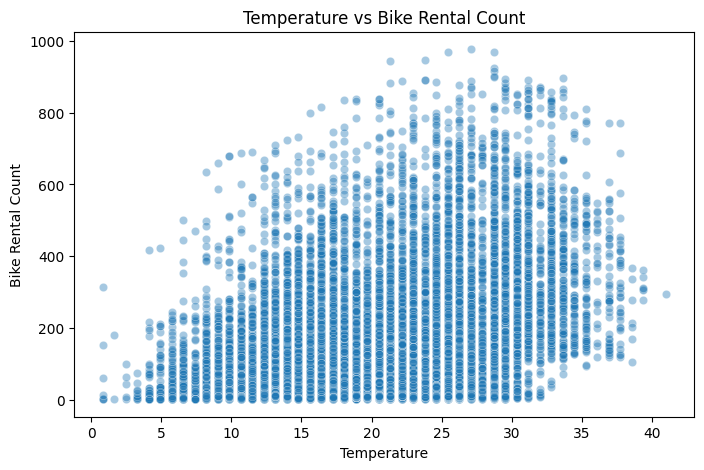

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temp', y='count', alpha=0.4)
plt.title('Temperature vs Bike Rental Count')
plt.xlabel('Temperature')
plt.ylabel('Bike Rental Count')
plt.show()

Bike rental demand generally increases as temperature rises, reaching higher levels at moderate temperatures. However, demand tends to decrease at very high temperatures, indicating a non-linear relationship between temperature and rental demand.


In [12]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

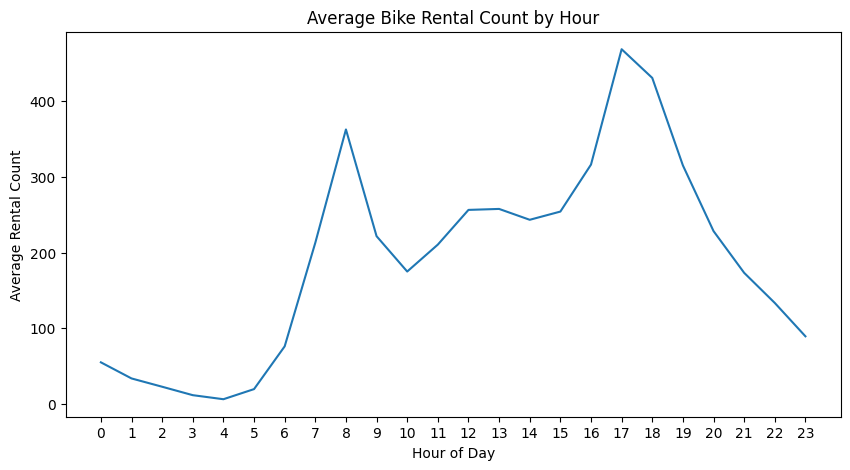

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='hour', y='count', errorbar=None)
plt.title('Average Bike Rental Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rental Count')
plt.xticks(range(24))
plt.show()

Bike rental demand varies considerably throughout the day, with clear peaks during the morning and evening hours and lower demand during the early morning. This indicates that the time of day is an important factor affecting rental demand.


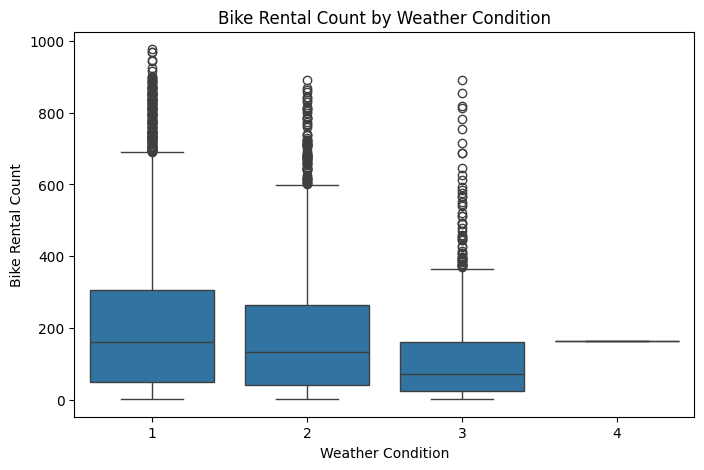

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='weather', y='count')
plt.title('Bike Rental Count by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Bike Rental Count')
plt.show()

Rental demand tends to decline as weather conditions worsen. The data also contains a few unusually high rental values, suggesting that high demand can still occur during unfavorable weather conditions.

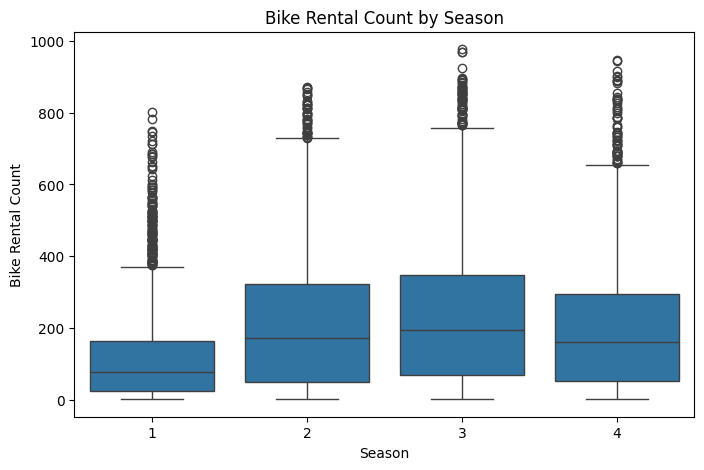

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='season', y='count')
plt.title('Bike Rental Count by Season')
plt.xlabel('Season')
plt.ylabel('Bike Rental Count')
plt.show()

Bike rental demand varies across seasons, with lower demand in Season 1 and higher demand in Seasons 2–4. Several high-demand outliers are also present across all seasons, indicating that other factors influence rental demand.

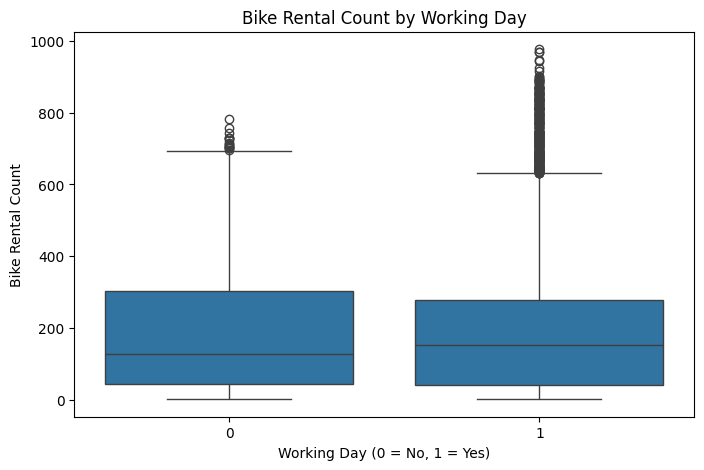

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='workingday', y='count')
plt.title('Bike Rental Count by Working Day')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Bike Rental Count')
plt.show()

Rental demand is similar on working and non-working days. However, working days have some higher-demand periods, suggesting that workingday may affect when people rent bikes.

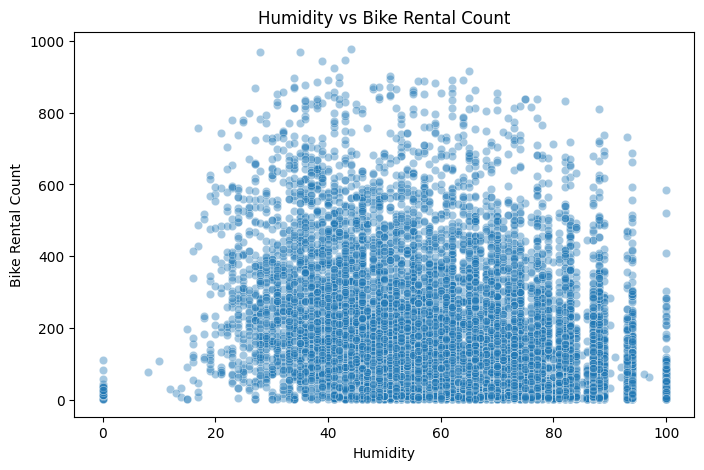

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='humidity', y='count', alpha=0.4)
plt.title('Humidity vs Bike Rental Count')
plt.xlabel('Humidity')
plt.ylabel('Bike Rental Count')
plt.show()

Rental demand shows a weak negative relationship with humidity. Higher humidity generally has lower rental demand, but the relationship is not very strong.

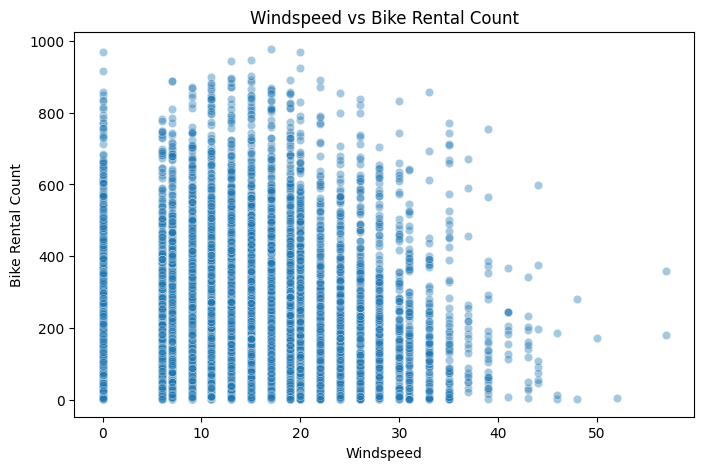

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='windspeed', y='count', alpha=0.4)
plt.title('Windspeed vs Bike Rental Count')
plt.xlabel('Windspeed')
plt.ylabel('Bike Rental Count')
plt.show()

Rental demand generally decreases as windspeed increases. Higher windspeed is associated with lower rental demand, although other factors also affect the number of rentals.

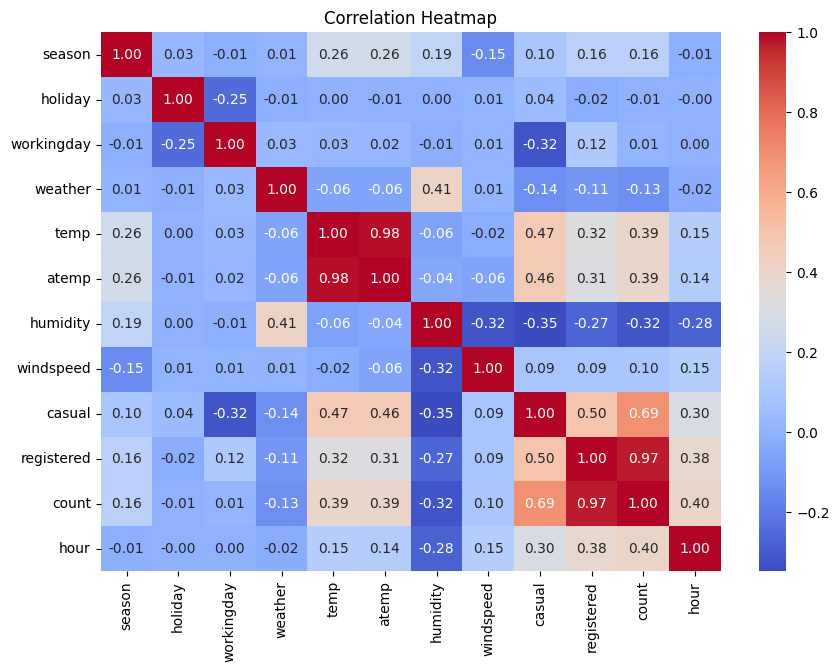

In [19]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

The heatmap shows that hour and temp have noticeable relationships with rental demand. temp and atemp are highly correlated, while casual and registered are strongly related to count, so they should not be used as input features because they are part of the target.

In [20]:
df[df['humidity'] == 0]

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour
1091,2011-03-10 00:00:00,1,0,1,3,13.94,15.910,0,16.9979,3,0,3,0
1092,2011-03-10 01:00:00,1,0,1,3,13.94,15.910,0,16.9979,0,2,2,1
1093,2011-03-10 02:00:00,1,0,1,3,13.94,15.910,0,16.9979,0,1,1,2
1094,2011-03-10 05:00:00,1,0,1,3,14.76,17.425,0,12.9980,1,2,3,5
1095,2011-03-10 06:00:00,1,0,1,3,14.76,16.665,0,22.0028,0,12,12,6
1096,2011-03-10 07:00:00,1,0,1,3,15.58,19.695,0,15.0013,1,36,37,7
1097,2011-03-10 08:00:00,1,0,1,3,15.58,19.695,0,19.0012,1,43,44,8
1098,2011-03-10 09:00:00,1,0,1,3,16.40,20.455,0,15.0013,1,23,24,9
1099,2011-03-10 10:00:00,1,0,1,3,16.40,20.455,0,11.0014,0,17,17,10
1100,2011-03-10 11:00:00,1,0,1,3,16.40,20.455,0,16.9979,6,5,11,11


In [21]:
print("Number of rows with humidity = 0:", (df['humidity'] == 0).sum())

Number of rows with humidity = 0: 22


In [23]:
df['humidity'] = df['humidity'].replace(0, np.nan)
df['humidity'] = df['humidity'].fillna(df['humidity'].median())
print("Remaining missing values:", df['humidity'].isnull().sum())

Remaining missing values: 0


A total of 22 records had humidity recorded as '0'. These values were treated as missing and replaced with the median humidity to avoid removing valid records.


In [24]:
df['weather'].value_counts().sort_index()

,count
weather,
1,7192
2,2834
3,859
4,1


Weather category 4 appears only once, while categories 1 and 2 contain most of the records. Since the value is valid, it will be retained rather than removed.


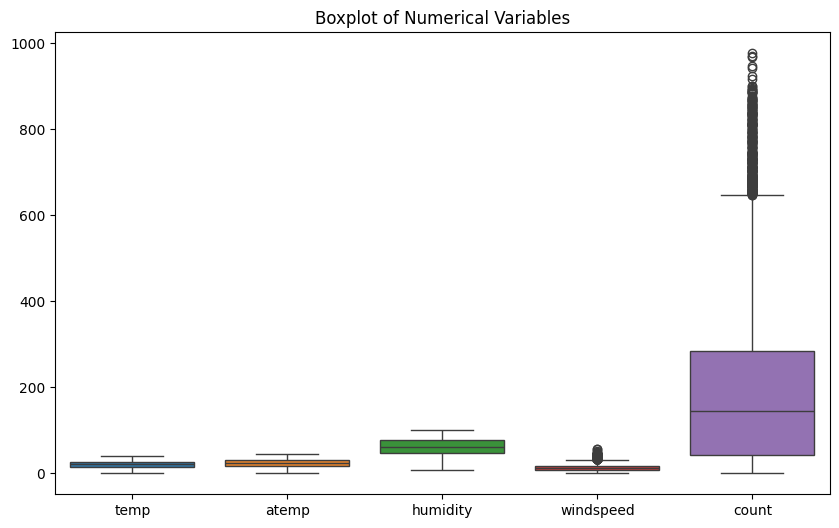

In [25]:
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'count']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot of Numerical Variables')
plt.show()

The boxplot shows some high-value outliers in count and windspeed. These values may represent genuine observations, so they will not be removed automatically and will be considered during model development.

In [27]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print(df[['datetime', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend']].head())

             datetime  year  month  day  hour  day_of_week  is_weekend
0 2011-01-01 00:00:00  2011      1    1     0            5           1
1 2011-01-01 01:00:00  2011      1    1     1            5           1
2 2011-01-01 02:00:00  2011      1    1     2            5           1
3 2011-01-01 03:00:00  2011      1    1     3            5           1
4 2011-01-01 04:00:00  2011      1    1     4            5           1


In [28]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

In [29]:
print(df.columns)

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'hour', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'hour_sin',
       'hour_cos'],
      dtype='object')


In [30]:
print(df[['hour', 'hour_sin', 'hour_cos',
          'year', 'month', 'day',
          'day_of_week', 'is_weekend']].head())

   hour  hour_sin  hour_cos  year  month  day  day_of_week  is_weekend
0     0  0.000000  1.000000  2011      1    1            5           1
1     1  0.258819  0.965926  2011      1    1            5           1
2     2  0.500000  0.866025  2011      1    1            5           1
3     3  0.707107  0.707107  2011      1    1            5           1
4     4  0.866025  0.500000  2011      1    1            5           1


In [31]:
y = df['count']
X = df.drop(columns=['count', 'casual', 'registered', 'datetime'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10886, 16)
y shape: (10886,)


In [32]:
print(X.columns.tolist())

['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos']


In [33]:
categorical_features = [
    'season',
    'holiday',
    'workingday',
    'weather',
    'year',
    'month',
    'day_of_week',
    'is_weekend'
]

In [34]:
numerical_features = [
    'temp',
    'atemp',
    'humidity',
    'windspeed',
    'hour',
    'day',
    'hour_sin',
    'hour_cos'
]

In [35]:
X = X.drop(columns=['atemp'])

print("New X shape:", X.shape)
print(X.columns.tolist())

New X shape: (10886, 15)
['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'hour', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos']


In [37]:
numerical_features = [
    'temp',
    'humidity',
    'windspeed',
    'hour',
    'day',
    'hour_sin',
    'hour_cos'
]

In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [40]:
df = df.sort_values('datetime').reset_index(drop=True)
X = df.drop(columns=['count', 'casual', 'registered', 'datetime', 'atemp'])
y = df['count']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10886, 15)
y shape: (10886,)


In [41]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7620, 15)
Validation set: (1632, 15)
Test set: (1634, 15)


In [42]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Validation data shape:", X_val_processed.shape)
print("Test data shape:", X_test_processed.shape)

Training data shape: (7620, 42)
Validation data shape: (1632, 42)
Test data shape: (1634, 42)


In [44]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [45]:
y_val_pred_linear = linear_model.predict(X_val_processed)

print("First 10 predictions:")
print(y_val_pred_linear[:10])

First 10 predictions:
[289.73561054 267.48318151 243.79137798 177.50918926 163.75777813
 160.88549027 161.72930914 171.3107129  178.57794295 193.31902857]


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_val, y_val_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, y_val_pred_linear))
r2_linear = r2_score(y_val, y_val_pred_linear)

print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

MAE : 134.41217266127887
RMSE: 170.80568524418106
R²  : 0.41024456665044606


Linear Regression achieved an MAE of 134.41, RMSE of 170.81, and R² of 0.41 on the validation set. This provides a baseline for comparing more advanced regression models.


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [51]:
y_val_pred_rf = rf_model.predict(X_val_processed)

print("First 10 Random Forest predictions:")
print(y_val_pred_rf[:10])

First 10 Random Forest predictions:
[233.13 187.26  81.25  43.96  16.55  10.26   5.78   5.58  27.99 145.91]


In [52]:
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_rf = r2_score(y_val, y_val_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 50.499773284313726
RMSE: 77.52836293021868
R²  : 0.8784965711864119


Random Forest achieved an MAE of 50.50, RMSE of 77.53, and R² of 0.88 on the validation set. Compared with Linear Regression, it captures the non-linear patterns in bike rental demand more effectively.

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_processed, y_train)
print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [55]:
y_val_pred_gb = gb_model.predict(X_val_processed)

print("First 10 Gradient Boosting predictions:")
print(y_val_pred_gb[:10])

First 10 Gradient Boosting predictions:
[228.60244828 187.61261948 147.57046214  51.56631884  40.36605888
  34.54759354  33.67751867  56.80834953  22.5203223  144.07360331]


In [56]:
mae_gb = mean_absolute_error(y_val, y_val_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
r2_gb = r2_score(y_val, y_val_pred_gb)

print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

MAE : 69.6092611639705
RMSE: 96.49151900873532
R²  : 0.8117887438648392


Random Forest achieved the lowest MAE and RMSE and the highest R² among the three validation experiments. This indicates that it captures the non-linear patterns in bike rental demand more effectively than the other tested models.

In [57]:
rf_model_200 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model_200.fit(X_train_processed, y_train)

print("Random Forest (200 trees) trained successfully!")

Random Forest (200 trees) trained successfully!


In [58]:
y_val_pred_rf_200 = rf_model_200.predict(X_val_processed)

print("First 10 predictions:")
print(y_val_pred_rf_200[:10])

First 10 predictions:
[234.75  183.405  81.235  45.54   16.315  10.61    6.01    5.685  27.82
 147.465]


In [59]:
mae_rf_200 = mean_absolute_error(y_val, y_val_pred_rf_200)
rmse_rf_200 = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_200))
r2_rf_200 = r2_score(y_val, y_val_pred_rf_200)

print("MAE :", mae_rf_200)
print("RMSE:", rmse_rf_200)
print("R²  :", r2_rf_200)

MAE : 50.70467524509804
RMSE: 77.61627922264535
R²  : 0.8782208478954071


Increasing the Random Forest from 100 to 200 trees did not improve validation performance. The 100-tree model achieved slightly lower MAE and RMSE and a slightly higher R², so additional trees did not provide a meaningful benefit in this experiment.

In [60]:
rf_model_depth = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_depth.fit(X_train_processed, y_train)

print("Random Forest (max_depth=15) trained successfully!")

Random Forest (max_depth=15) trained successfully!


In [61]:
y_val_pred_rf_depth = rf_model_depth.predict(X_val_processed)

mae_rf_depth = mean_absolute_error(y_val, y_val_pred_rf_depth)
rmse_rf_depth = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_depth))
r2_rf_depth = r2_score(y_val, y_val_pred_rf_depth)

print("MAE :", mae_rf_depth)
print("RMSE:", rmse_rf_depth)
print("R²  :", r2_rf_depth)

MAE : 50.610560825457924
RMSE: 77.68106632919311
R²  : 0.8780174624253355


In [62]:
y_train_pred_rf = rf_model.predict(X_train_processed)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
val_r2_rf = r2_score(y_val, y_val_pred_rf)

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
val_mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

print("Random Forest - Training vs Validation")
print("Training MAE:", train_mae_rf)
print("Validation MAE:", val_mae_rf)
print("Training R²:", train_r2_rf)
print("Validation R²:", val_r2_rf)

Random Forest - Training vs Validation
Training MAE: 8.022910761154856
Validation MAE: 50.499773284313726
Training R²: 0.9924253517503492
Validation R²: 0.8784965711864119


The Random Forest shows signs of overfitting, with a much higher training R² (0.992) than validation R² (0.878). However, its validation performance remains strong, indicating that the model still generalizes reasonably well to unseen data.

In [63]:
rf_model_depth10 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model_depth10.fit(X_train_processed, y_train)

print("Random Forest (max_depth=10) trained successfully!")

Random Forest (max_depth=10) trained successfully!


In [65]:
y_val_pred_rf_depth10 = rf_model_depth10.predict(X_val_processed)

mae_rf_depth10 = mean_absolute_error(y_val, y_val_pred_rf_depth10)
rmse_rf_depth10 = np.sqrt(mean_squared_error(y_val, y_val_pred_rf_depth10))
r2_rf_depth10 = r2_score(y_val, y_val_pred_rf_depth10)

print("Random Forest (max_depth=10) Results")
print("MAE :", mae_rf_depth10)
print("RMSE:", rmse_rf_depth10)
print("R²  :", r2_rf_depth10)

Random Forest (max_depth=10) Results
MAE : 53.61997067104439
RMSE: 80.29472882527452
R²  : 0.86967090544093


Reducing the maximum tree depth to 10 lowered validation performance, with R² decreasing from 0.8785 to 0.8697. This suggests that overly restricting tree depth prevents the model from capturing some useful patterns in bike rental demand.

In [66]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (100 trees)',
        'Random Forest (200 trees)',
        'Random Forest (max_depth=15)',
        'Random Forest (max_depth=10)',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_rf_200,
        mae_rf_depth,
        mae_rf_depth10,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_rf_200,
        rmse_rf_depth,
        rmse_rf_depth10,
        rmse_gb
    ],
    'R2': [
        r2_linear,
        r2_rf,
        r2_rf_200,
        r2_rf_depth,
        r2_rf_depth10,
        r2_gb
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,134.412173,170.805685,0.410245
1,Random Forest (100 trees),50.499773,77.528363,0.878497
2,Random Forest (200 trees),50.704675,77.616279,0.878221
3,Random Forest (max_depth=15),50.610561,77.681066,0.878017
4,Random Forest (max_depth=10),53.619971,80.294729,0.869671
5,Gradient Boosting,69.609261,96.491519,0.811789


In [67]:
y_test_pred = rf_model.predict(X_test_processed)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("Final Random Forest Test Results")
print("MAE :", mae_test)
print("RMSE:", rmse_test)
print("R²  :", r2_test)

Final Random Forest Test Results
MAE : 61.604051407588734
RMSE: 87.8276316208754
R²  : 0.8321712997269073


The final Random Forest model achieved an MAE of 61.60, an RMSE of 87.83, and an R² score of 0.8322 on the unseen test set. This means the model explains approximately 83.2% of the variation in bike rental demand, while its predictions differ from the actual rental counts by about 62 bikes on average.

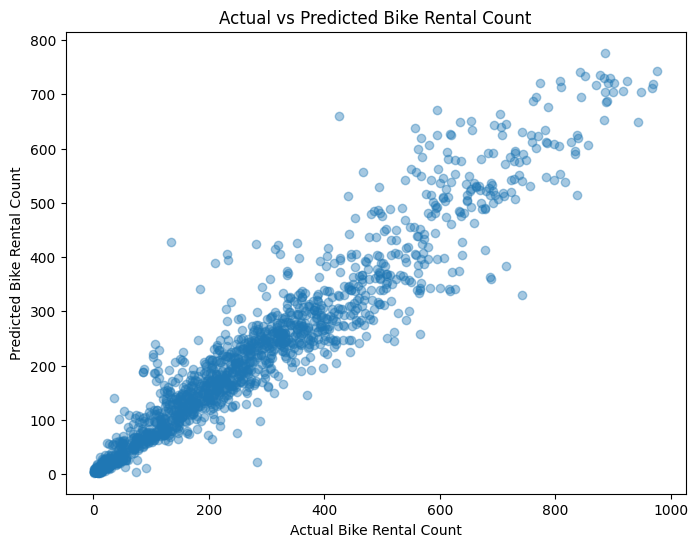

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.4)

plt.xlabel('Actual Bike Rental Count')
plt.ylabel('Predicted Bike Rental Count')
plt.title('Actual vs Predicted Bike Rental Count')

plt.show()

The actual vs predicted plot shows that the model captures the overall pattern of bike rental demand, with predictions generally following the actual values. The prediction error becomes larger for higher rental counts, and the model tends to underestimate some high-demand periods. This indicates that the model performs well overall but has more difficulty predicting extreme rental demand.


In [69]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__hour,0.383701
0,num__temp,0.147758
5,num__hour_sin,0.144449
6,num__hour_cos,0.074627
1,num__humidity,0.034333
20,cat__year_2012,0.027798
19,cat__year_2011,0.025690
14,cat__workingday_1,0.022978
13,cat__workingday_0,0.018486
17,cat__weather_3,0.014722


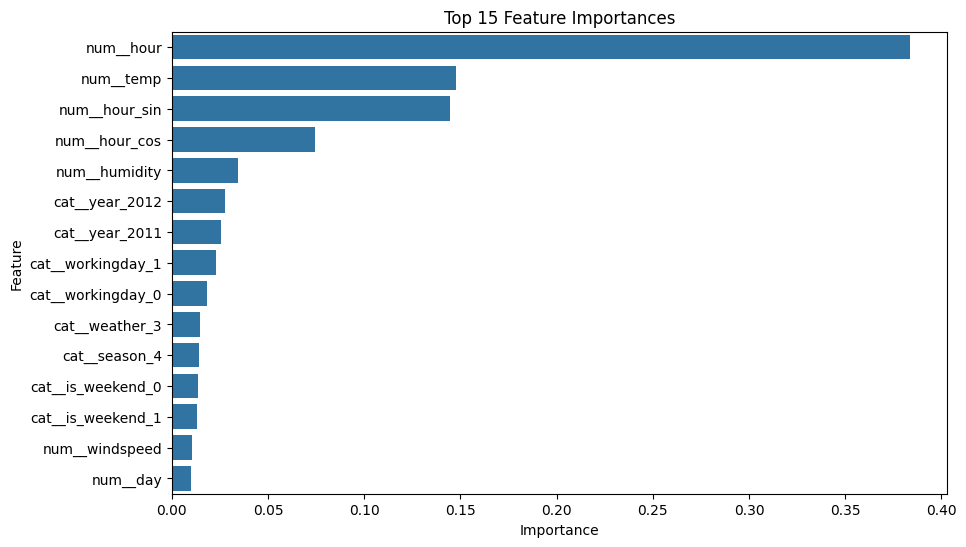

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Feature importance shows that hour is the most influential feature, followed by temp, hour_sin, and hour_cos. This indicates that time of day and temperature play major roles in predicting bike rental demand. Humidity, year, and working-day information also contribute to the predictions, while windspeed and day have relatively smaller importance in this model.


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

final_pipeline.fit(X_train, y_train)

print("Final model trained successfully!")

Final model trained successfully!


In [72]:
joblib.dump(final_pipeline, 'bike_demand_model.pkl')

print("Model saved successfully!")

Model saved successfully!
